# BEARING FAILURE PREDICTION USING MACHINE LEARNING

## EXPLORATORY DATA ANALYSIS TO UNDERSTAND THE DATASET

In [2]:
#  Import the Libraries needed 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Loading the dataset
df = pd.read_csv("feature_time_48k_2048_load_1.csv")
df.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [4]:
# shape of the dataset
df.shape

(2300, 10)

>the dataset contains `2,300` observations and `10` columns 

In [5]:
# Check for missing values
df.isnull().sum()

max         0
min         0
mean        0
sd          0
rms         0
skewness    0
kurtosis    0
crest       0
form        0
fault       0
dtype: int64

>There are no missing values in the dataset

In [6]:
# Check the info of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   max       2300 non-null   float64
 1   min       2300 non-null   float64
 2   mean      2300 non-null   float64
 3   sd        2300 non-null   float64
 4   rms       2300 non-null   float64
 5   skewness  2300 non-null   float64
 6   kurtosis  2300 non-null   float64
 7   crest     2300 non-null   float64
 8   form      2300 non-null   float64
 9   fault     2300 non-null   str    
dtypes: float64(9), str(1)
memory usage: 200.5 KB


In [7]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

>There are no duplicates in the dataset

In [8]:
# Check the descriptive statistics
df.describe()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,1.575079,-1.550994,0.015711,0.341601,0.342289,-0.042251,2.664444,4.173130,26.544769
std,1.578422,1.602706,0.006469,0.305279,0.304813,0.180774,4.411096,1.148349,29.209702
min,0.157300,-6.292600,0.003246,0.059140,0.061067,-1.089928,-0.803795,2.428511,3.484429
25%,0.456398,-2.174975,0.011236,0.135506,0.136374,-0.103426,-0.015164,3.260382,7.413359
50%,0.794510,-0.733700,0.013730,0.188551,0.190662,-0.002466,0.816970,3.921650,13.122811
75%,2.278425,-0.426987,0.018638,0.555589,0.555671,0.061093,3.902286,4.815876,39.911894
max,6.825900,-0.160220,0.038386,1.256577,1.256311,1.059512,30.385326,8.821577,313.742612


In [9]:
# Explore the Target Varible
df["fault"].value_counts()

fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Normal_1      230
Name: count, dtype: int64

> The dataset is balanced 

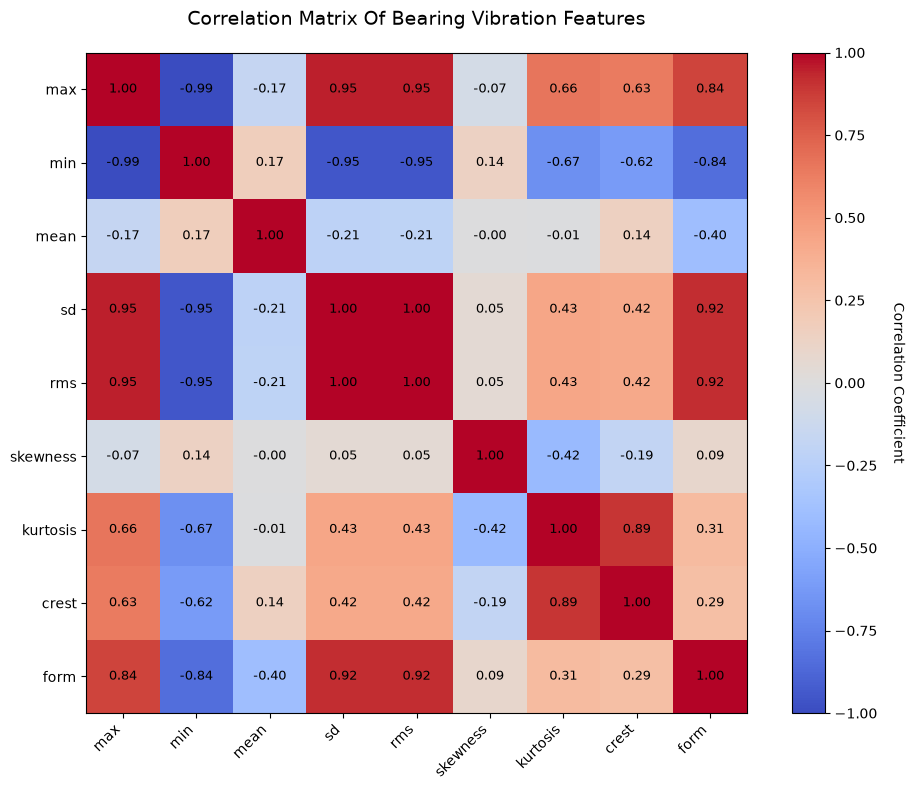

In [10]:
# Correlation heatmap
corr = df.drop(columns=['fault']).corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, cmap="coolwarm", interpolation="nearest", vmin=-1, vmax=1)

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Set ticks and labels
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix Of Bearing Vibration Features", fontsize=14, pad=20)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                        ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.savefig("bearing_correlation_matplotlib.png", dpi=150)
plt.show()

> Show the correlation heat map of the features

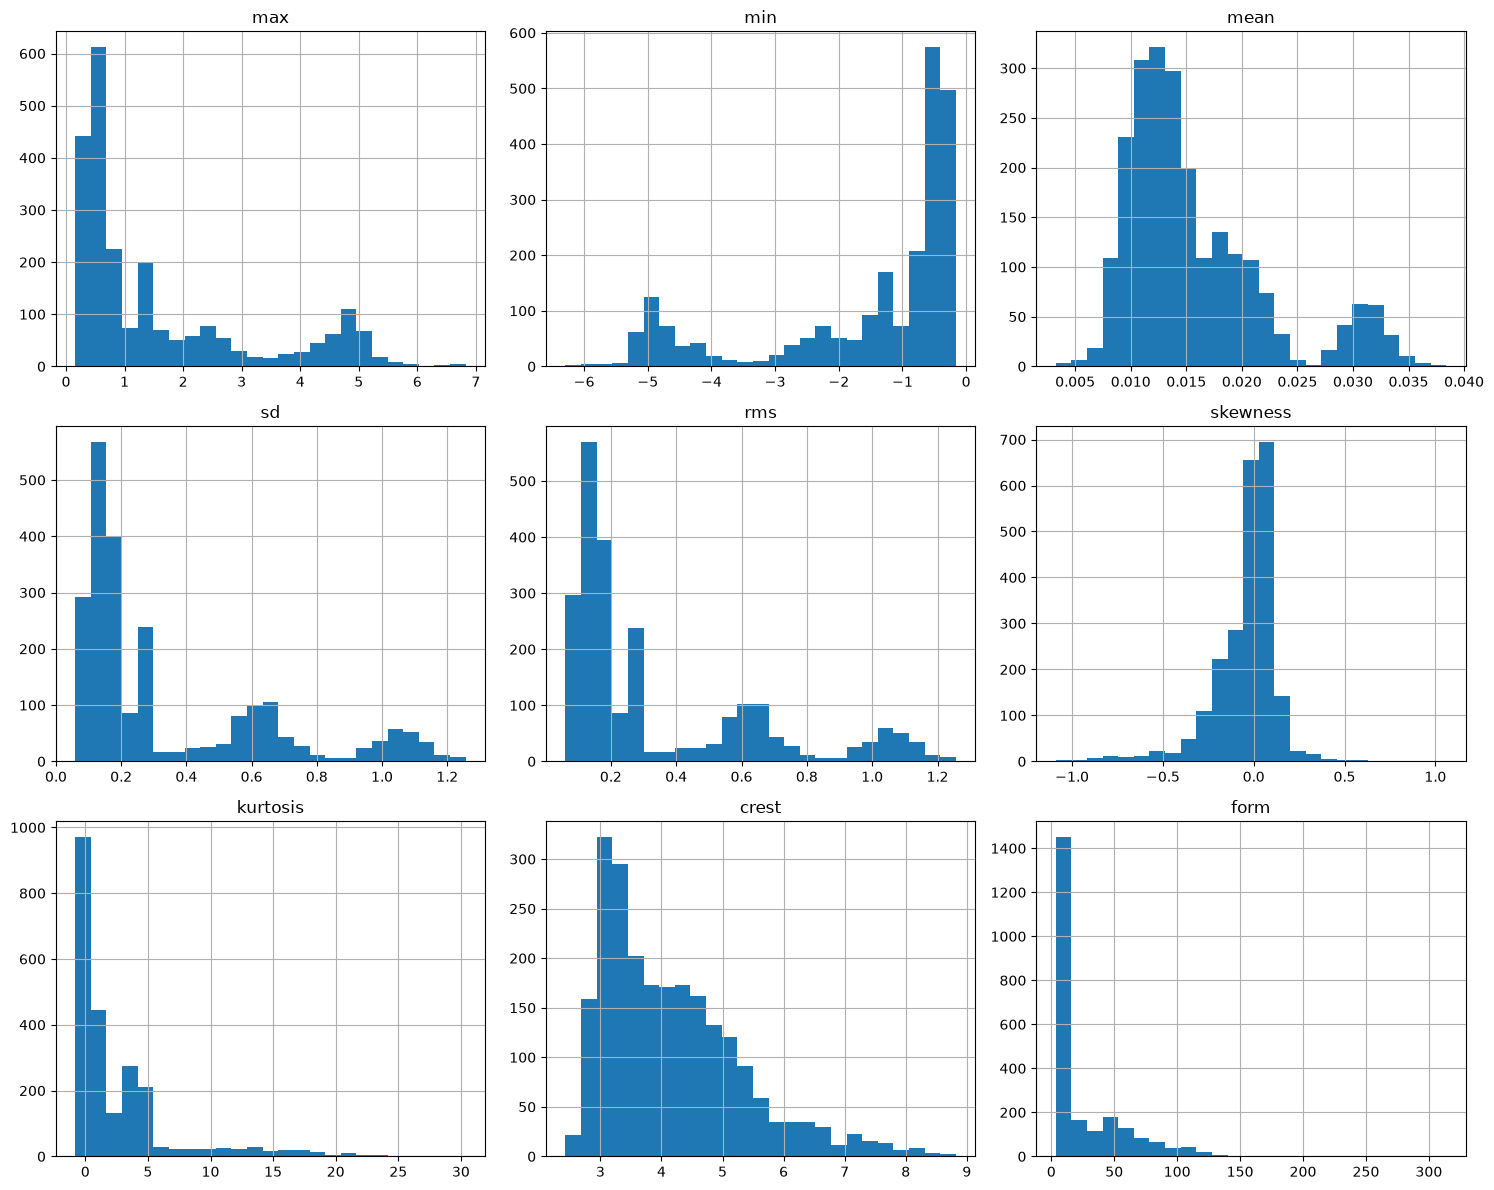

In [11]:
# Histogram of the dataset
df.hist(figsize=(15,12), bins=25)

plt.tight_layout()

plt.show()

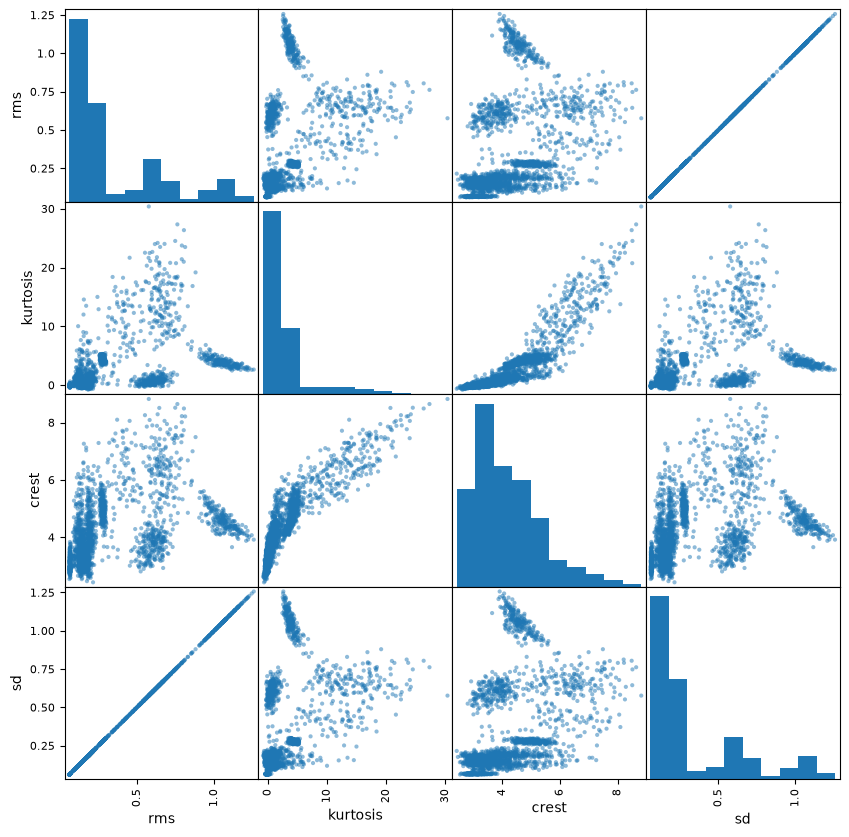

In [12]:
# Pairwise Relationship
pd.plotting.scatter_matrix(
    df[["rms", "kurtosis", "crest", "sd"]],
    figsize=(10,10),
    diagonal="hist"
)

plt.show()

> This lets us see whether any of these important vibration features naturally separate the fault classes.

## DATA PREPROCESSING

In [13]:
# Import the LIbraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [14]:
# Separate Features and Target
X = df.drop("fault", axis = 1)
y = df["fault"]

In [15]:
# cofirming the shape of the Target and the features
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (2300, 9)
Target: (2300,)


In [16]:
# Encoding the Target Variable
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [17]:
# Check the encoded values
print(encoder.classes_)

['Ball_007_1' 'Ball_014_1' 'Ball_021_1' 'IR_007_1' 'IR_014_1' 'IR_021_1'
 'Normal_1' 'OR_007_6_1' 'OR_014_6_1' 'OR_021_6_1']


In [18]:
print(y_encoded[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [19]:
# saving the mapping 
label_mapping = dict(zip(encoder.classes_,
                        encoder.transform(encoder.classes_)))

label_mapping

{'Ball_007_1': np.int64(0),
 'Ball_014_1': np.int64(1),
 'Ball_021_1': np.int64(2),
 'IR_007_1': np.int64(3),
 'IR_014_1': np.int64(4),
 'IR_021_1': np.int64(5),
 'Normal_1': np.int64(6),
 'OR_007_6_1': np.int64(7),
 'OR_014_6_1': np.int64(8),
 'OR_021_6_1': np.int64(9)}

In [20]:
# Split the dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y_encoded, 
                                                   random_state = 42,
                                                   test_size = 0.2,
                                                   stratify = y_encoded)

In [21]:
# confirming the set sizes
print(f"Train Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

Train Set: (1840, 9)
Test Set: (460, 9)


In [22]:
# Scaling the Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled[:5]

array([[-0.67530375,  0.66823456, -0.21425947, -0.66538629, -0.66633777,
        -0.04962203, -0.50831544, -0.46352332, -0.58265586],
       [-0.66399023,  0.68847663, -0.13787192, -0.69643511, -0.69706795,
         0.26010452, -0.40607668, -0.11850457, -0.61604184],
       [ 2.17322501, -2.15512063, -0.54118787,  2.36787996,  2.36861264,
         0.71016571,  0.2041212 ,  0.48197768,  2.11852472],
       [-0.00358713,  0.09544928,  0.81299175, -0.23601857, -0.23617079,
        -0.38945529,  0.50710266,  1.42296957, -0.47201277],
       [-0.51729915,  0.55121612,  2.30510667, -0.528996  , -0.5237201 ,
         0.41613577, -0.37376084, -0.02431437, -0.71410812]])

> we fit the scaler only on the training data and transform the test data. This prevents information from the test set leaking into the training process.

### Save the Label Encoder and the Scaler

In [24]:
# Save the encoder
import joblib
joblib.dump(
    encoder,
    "label_encoder.pkl"
)


['label_encoder.pkl']

In [25]:
# Save the Scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

## FEATURE SELECTION

**Objective**: identify features that contribute most to predictive performance, reduce redundancy, and improve model interpretability.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### **Extract Feature Importance**

In [27]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
4,rms,0.204352
3,sd,0.196609
2,mean,0.163090
6,kurtosis,0.115210
0,max,0.088834
1,min,0.086502
8,form,0.076358
7,crest,0.055699
5,skewness,0.013346


**Plot the Result**

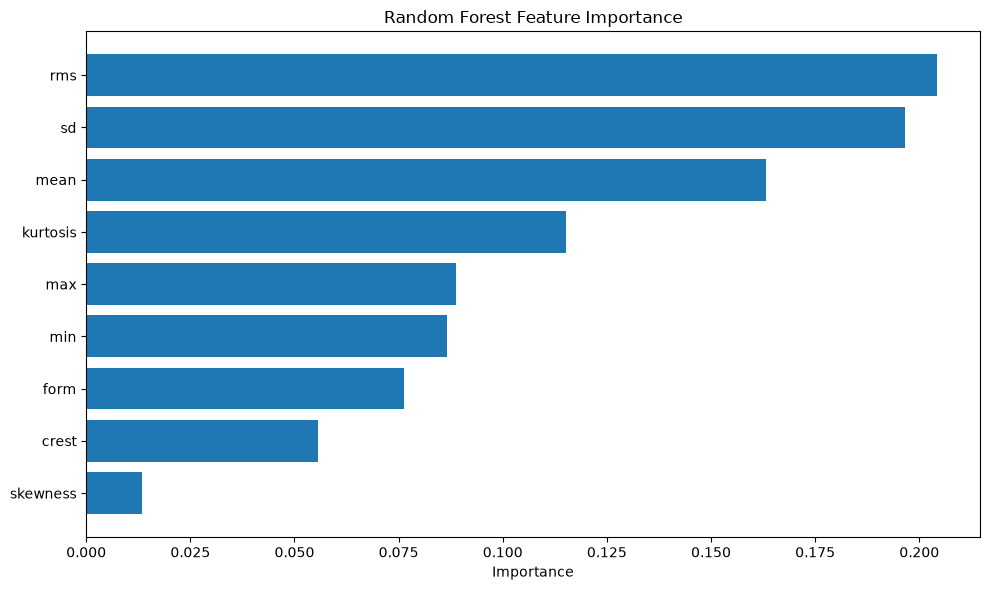

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
# plt.savefig(r"C:\Users\McImaga\Desktop\playground\project-bearing-failure-prediction\figures\figure7_Random_Forest_Feature_Importance.png", dpi = 150)
plt.show()

### Mutual Information

In [29]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Mutual Information": mi
})

mi_df = mi_df.sort_values(
    "Mutual Information",
    ascending=False
)

mi_df

,Feature,Mutual Information
4,rms,1.697986
3,sd,1.687690
0,max,1.565239
1,min,1.559002
8,form,1.342434
6,kurtosis,1.080105
2,mean,0.793908
7,crest,0.760476
5,skewness,0.514775


**Plot Mutual Information**

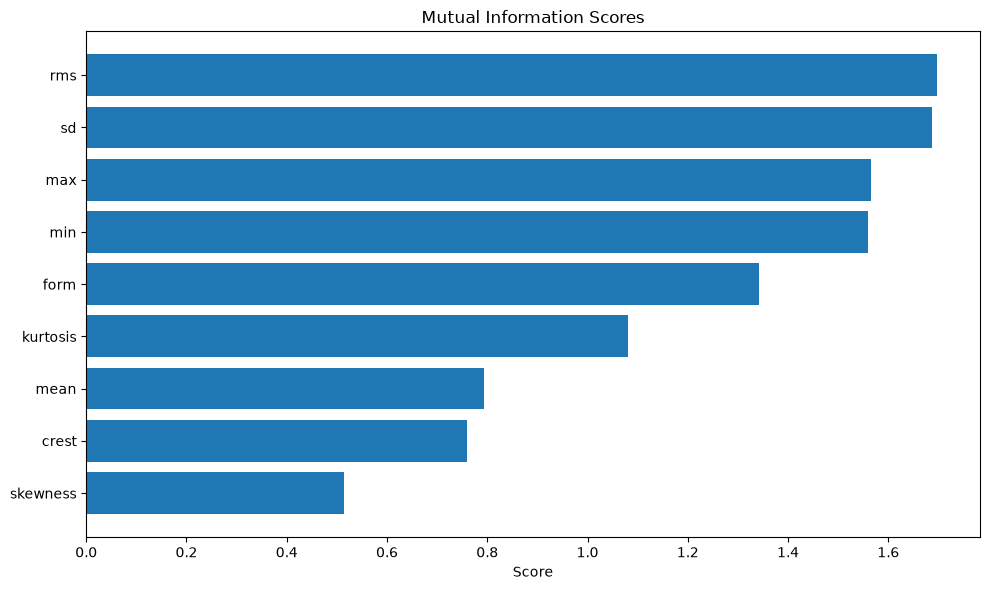

In [61]:
plt.figure(figsize=(10,6))

plt.barh(
    mi_df["Feature"],
    mi_df["Mutual Information"]
)

plt.xlabel("Score")

plt.title("Mutual Information Scores")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("Random_mutual_information.png", dpi = 150)

plt.show()

### Compare the Rankings

In [31]:
comparison = importance.merge(
    mi_df,
    on = "Feature"
)

comparison

,Feature,Importance,Mutual Information
0,rms,0.204352,1.697986
1,sd,0.196609,1.687690
2,mean,0.163090,0.793908
3,kurtosis,0.115210,1.080105
4,max,0.088834,1.565239
5,min,0.086502,1.559002
6,form,0.076358,1.342434
7,crest,0.055699,0.760476
8,skewness,0.013346,0.514775


> Feature importance analysis was conducted using both Random Forest feature importance and Mutual Information. The results indicate that Root Mean Square (RMS) and Standard Deviation are the most influential features for bearing fault classification. These features quantify the overall vibration energy and variability of the signal, respectively, both of which increase as bearing defects develop. Kurtosis also exhibited a high relevance score, indicating its effectiveness in capturing impulsive behaviour associated with localised bearing defects. In contrast, skewness consistently ranked as the least informative feature across both methods, suggesting that it contributes comparatively little discriminatory information for this dataset.

## MODEL BUILDING

**Objective:**
Train and evaluate a Logistic Regression model to establish
a baseline for comparison with more advanced classifiers.


In [32]:
# Import the requirred Libraries

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


### Define Helper Functions

In [33]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Train a model and evaluate its performance.

    Parameters
    ----------
    model : sklearn estimator
        Machine learning model.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    print("=" * 60)
    print(model.__class__.__name__)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Predictions": predictions
    }

# Confusion Matrix reusable function


def plot_confusion_matrix(model, X_test, y_test):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(model.__class__.__name__)

    plt.tight_layout()
    
    plt.savefig(model.__class__.__name__)

    plt.show()


In [34]:
X_train = X_train_scaled 
X_test = X_test_scaled 

In [35]:
# confirm the shapes
print(X_train.shape)
print(X_test.shape)

(1840, 9)
(460, 9)


## MODEL COMPARISON

Here we will develop and compare five different models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbours (KNN)
5. Support Vector Machine (SVM)

### **Train The Baseline Model**

In [36]:
baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

results = evaluate_model(
    baseline,
    X_train,
    y_train,
    X_test,
    y_test
)

LogisticRegression
Accuracy : 0.9065
Precision: 0.9087
Recall   : 0.9065
F1 Score : 0.9046

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        46
           1       0.91      0.65      0.76        46
           2       0.79      0.74      0.76        46
           3       0.96      1.00      0.98        46
           4       1.00      1.00      1.00        46
           5       0.92      1.00      0.96        46
           6       0.92      1.00      0.96        46
           7       1.00      1.00      1.00        46
           8       0.70      0.80      0.75        46
           9       0.98      0.96      0.97        46

    accuracy                           0.91       460
   macro avg       0.91      0.91      0.90       460
weighted avg       0.91      0.91      0.90       460



**Confusion Matrix**

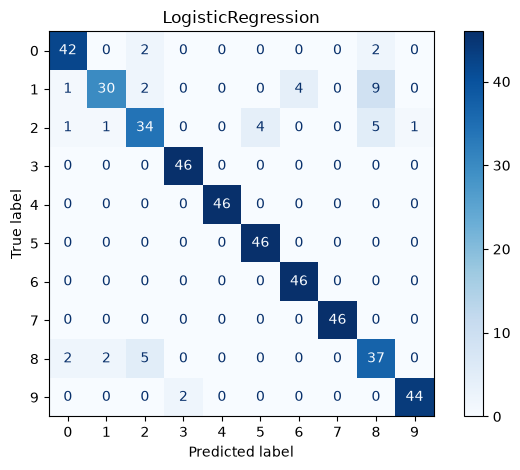

In [37]:
plot_confusion_matrix(
    baseline,
    X_test,
    y_test
)

### Decision Tree

In [38]:
decision_tree = DecisionTreeClassifier(
    random_state = 42
)

dt_results = evaluate_model(
    decision_tree,
    X_train,
    y_train,
    X_test,
    y_test
)

DecisionTreeClassifier
Accuracy : 0.9326
Precision: 0.9354
Recall   : 0.9326
F1 Score : 0.9326

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        46
           1       0.97      0.80      0.88        46
           2       0.84      0.80      0.82        46
           3       0.98      0.98      0.98        46
           4       1.00      1.00      1.00        46
           5       0.94      1.00      0.97        46
           6       1.00      1.00      1.00        46
           7       1.00      1.00      1.00        46
           8       0.75      0.87      0.81        46
           9       0.96      1.00      0.98        46

    accuracy                           0.93       460
   macro avg       0.94      0.93      0.93       460
weighted avg       0.94      0.93      0.93       460



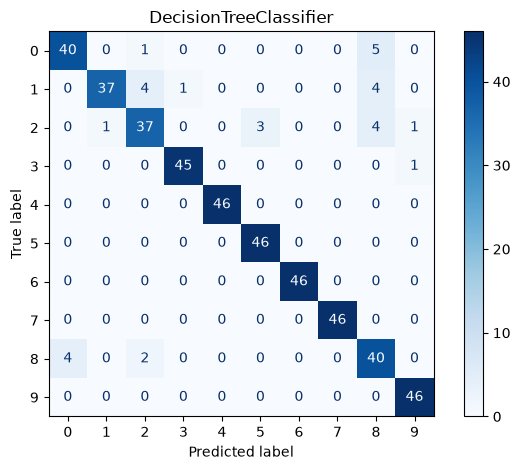

In [39]:
plot_confusion_matrix(
    decision_tree,
    X_test,
    y_test
)

### Random Tree

In [40]:
random_forest = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

rf_results = evaluate_model(
    random_forest,
    X_train,
    y_train,
    X_test,
    y_test
)

RandomForestClassifier
Accuracy : 0.9435
Precision: 0.9465
Recall   : 0.9435
F1 Score : 0.9438

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.87      0.92        46
           1       0.95      0.89      0.92        46
           2       0.88      0.80      0.84        46
           3       1.00      1.00      1.00        46
           4       1.00      1.00      1.00        46
           5       0.94      1.00      0.97        46
           6       1.00      1.00      1.00        46
           7       0.98      1.00      0.99        46
           8       0.76      0.89      0.82        46
           9       0.98      0.98      0.98        46

    accuracy                           0.94       460
   macro avg       0.95      0.94      0.94       460
weighted avg       0.95      0.94      0.94       460



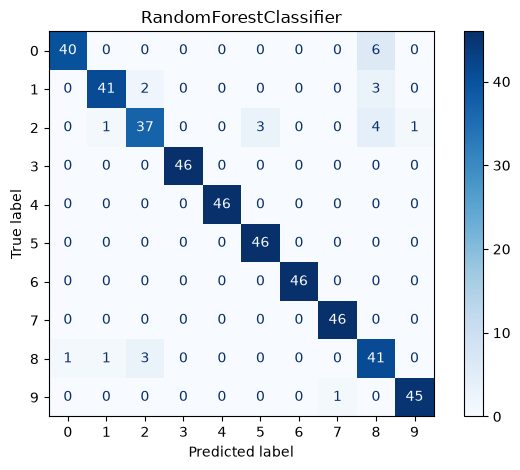

In [41]:
plot_confusion_matrix(
    random_forest,
    X_test,
    y_test
)

### K-Nearest Neighbours

In [42]:
knn = KNeighborsClassifier(
    n_neighbors = 5
)

knn_results = evaluate_model(
    knn,
    X_train,
    y_train,
    X_test,
    y_test
)

KNeighborsClassifier
Accuracy : 0.9087
Precision: 0.9173
Recall   : 0.9087
F1 Score : 0.9090

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.83      0.88        46
           1       0.91      0.70      0.79        46
           2       0.83      0.74      0.78        46
           3       0.98      1.00      0.99        46
           4       1.00      1.00      1.00        46
           5       0.92      1.00      0.96        46
           6       0.96      0.98      0.97        46
           7       1.00      1.00      1.00        46
           8       0.65      0.87      0.74        46
           9       0.98      0.98      0.98        46

    accuracy                           0.91       460
   macro avg       0.92      0.91      0.91       460
weighted avg       0.92      0.91      0.91       460



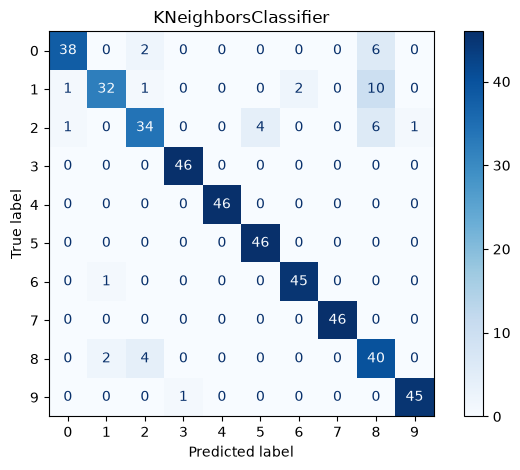

In [43]:
plot_confusion_matrix(
    knn,
    X_test,
    y_test
)

### Support Vector Machine

In [44]:
svm = SVC(
    kernel = "rbf",
    random_state = 42
)

svm_results = evaluate_model(
    svm,
    X_train,
    y_train,
    X_test,
    y_test
)

SVC
Accuracy : 0.9130
Precision: 0.9224
Recall   : 0.9130
F1 Score : 0.9115

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        46
           1       0.93      0.61      0.74        46
           2       0.90      0.76      0.82        46
           3       0.98      1.00      0.99        46
           4       1.00      1.00      1.00        46
           5       0.92      1.00      0.96        46
           6       0.94      1.00      0.97        46
           7       1.00      0.98      0.99        46
           8       0.67      0.91      0.77        46
           9       0.96      0.98      0.97        46

    accuracy                           0.91       460
   macro avg       0.92      0.91      0.91       460
weighted avg       0.92      0.91      0.91       460



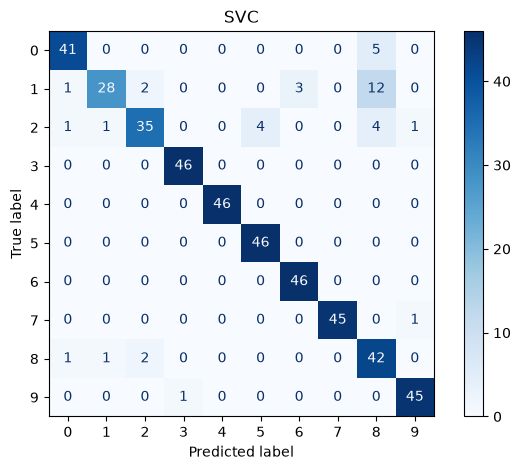

In [45]:
plot_confusion_matrix(
    svm,
    X_test,
    y_test
)

### Model Comparison

In [46]:
comparison = pd.DataFrame([
    {
        "Model": results["Model"],
        "Accuracy": results["Accuracy"],
        "Precision": results["Precision"],
        "Recall": results["Recall"],
        "F1 Score": results["F1 Score"]
    },
    {
        "Model": dt_results["Model"],
        "Accuracy": dt_results["Accuracy"],
        "Precision": dt_results["Precision"],
        "Recall": dt_results["Recall"],
        "F1 Score": dt_results["F1 Score"]
    },
    {
        "Model": rf_results["Model"],
        "Accuracy": rf_results["Accuracy"],
        "Precision": rf_results["Precision"],
        "Recall": rf_results["Recall"],
        "F1 Score": rf_results["F1 Score"]
    },
    {
        "Model": knn_results["Model"],
        "Accuracy": knn_results["Accuracy"],
        "Precision": knn_results["Precision"],
        "Recall": knn_results["Recall"],
        "F1 Score": knn_results["F1 Score"]
    },
    {
        "Model": svm_results["Model"],
        "Accuracy": svm_results["Accuracy"],
        "Precision": svm_results["Precision"],
        "Recall": svm_results["Recall"],
        "F1 Score": svm_results["F1 Score"]
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.906522,0.908706,0.906522,0.904648
1,DecisionTreeClassifier,0.932609,0.935377,0.932609,0.932555
2,RandomForestClassifier,0.943478,0.946507,0.943478,0.943773
3,KNeighborsClassifier,0.908696,0.917315,0.908696,0.908978
4,SVC,0.913043,0.922420,0.913043,0.911488


> Among the evaluated classifiers, the Random Forest algorithm achieved the highest classification accuracy of `94.35%`, outperforming Logistic Regression, Decision Tree, K-Nearest Neighbours, and Support Vector Machine. The ensemble learning strategy adopted by Random Forest enables it to capture complex, non-linear relationships within the vibration features while reducing overfitting through bootstrap aggregation. Analysis of the confusion matrix revealed that most bearing conditions were correctly classified, with only a small number of misclassifications occurring between fault classes exhibiting similar statistical characteristics.


## HYPEPARAMETER TUNING

**Objective:** Rather than accepting the default settings, we search for a better combination of parameters to improve the Random Forest Classifier

### Define the Parameter Grid

In [47]:
# Import the GridSearchCV Module
from sklearn.model_selection import GridSearchCV

In [48]:
param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [None, 10, 20],
    "min_samples_split" : [2, 5],
    "min_samples_leaf" : [1, 2]
}

### Create the Grid Search

In [49]:
rf = RandomForestClassifier(random_state = 42)

grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

### Fit the Grid Search

In [50]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

### View the Best Parameter

In [51]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.9690217391304348


### Evaluate the Best Model

In [52]:
best_rf = grid_search.best_estimator_

predictions = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Test Accuracy: {accuracy:.4f}")

print(classification_report(y_test, predictions))

Test Accuracy: 0.9457
              precision    recall  f1-score   support

           0       0.95      0.87      0.91        46
           1       1.00      0.87      0.93        46
           2       0.88      0.83      0.85        46
           3       1.00      1.00      1.00        46
           4       1.00      1.00      1.00        46
           5       0.94      1.00      0.97        46
           6       1.00      1.00      1.00        46
           7       0.98      1.00      0.99        46
           8       0.76      0.91      0.83        46
           9       0.98      0.98      0.98        46

    accuracy                           0.95       460
   macro avg       0.95      0.95      0.95       460
weighted avg       0.95      0.95      0.95       460



### Confusion Matrix

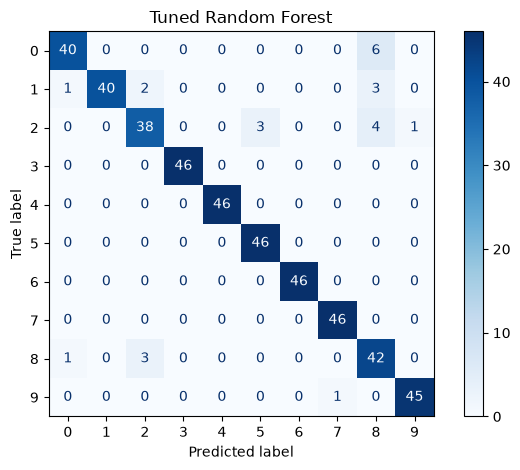

In [53]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Tuned Random Forest")

plt.tight_layout()

plt.savefig(r"C:\Users\McImaga\Desktop\playground\project-bearing-failure-prediction\figures\Tuned_RF_CM.png", dpi = 150)

plt.show()


## Final Model

**Objective:**
Train the final Random Forest Model using the optimal hyperparameters obtained from GridSearchCV.
Evaluate and serve the trained model.

### Create the Final Model

In [54]:
final_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    min_samples_leaf = 2,
    min_samples_split = 5,
    random_state = 42
    
)

### Train the Model

In [55]:
final_model.fit(X_train, y_train)

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Make Prediction

In [56]:
predictions = final_model.predict(X_test)

### Final Evaluation 

In [57]:
accuracy = accuracy_score(y_test, predictions)

print(f"Final Accuracy: {accuracy:.4f}")

print(classification_report(y_test, predictions))

Final Accuracy: 0.9457
              precision    recall  f1-score   support

           0       0.95      0.87      0.91        46
           1       1.00      0.87      0.93        46
           2       0.88      0.83      0.85        46
           3       1.00      1.00      1.00        46
           4       1.00      1.00      1.00        46
           5       0.94      1.00      0.97        46
           6       1.00      1.00      1.00        46
           7       0.98      1.00      0.99        46
           8       0.76      0.91      0.83        46
           9       0.98      0.98      0.98        46

    accuracy                           0.95       460
   macro avg       0.95      0.95      0.95       460
weighted avg       0.95      0.95      0.95       460



### Test on a Single Sample

In [58]:
sample = X_test[[0]]

prediction = final_model.predict(sample)

print(prediction)

[4]


### Convert the prediction back to the Original class name

In [59]:
fault_name = encoder.inverse_transform(prediction)

print(fault_name)

['IR_014_1']


### Save the Model

In [60]:
joblib.dump(
    final_model,
    "random_forest_model.pkl"
)

['random_forest_model.pkl']